In [1]:
#pca_analysis
  #Principal Component Analysis

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

x = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [41]:
x = pd.DataFrame (data.data , columns=data.feature_names)
y =pd.Series(data.target) # output is 0 or 1



In [42]:
#Standardization
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled , columns = x.columns)


In [43]:
# Apply PCA
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

In [44]:
pca_df = pd.DataFrame( x_pca , columns = ["Principle Component 1" , "Principle Component 2"])
pca_df ["target"] = y

In [45]:
# Variance Ration Explanations
print("explained variance ratio:")
print(pca.explained_variance_ratio_)
#PC1 explains about 44% of the variance
#PC2 explains about 18%
#Together they preserve about 62% of the information

explained variance ratio:
[0.44272026 0.18971182]


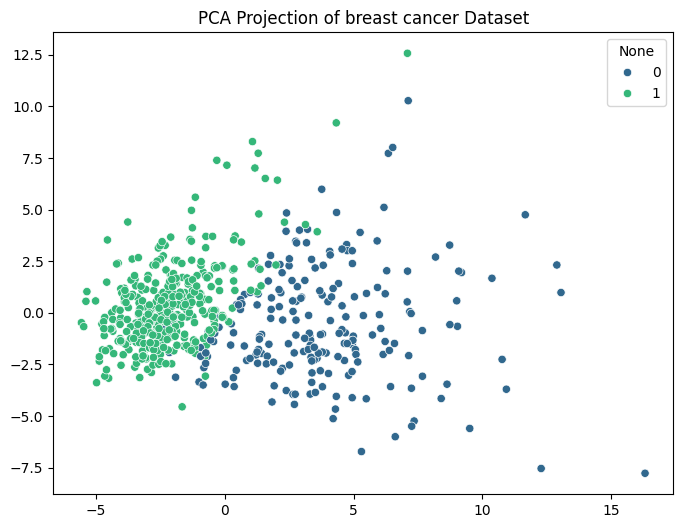

In [46]:
#Visual PCA visulization
x_pca = pca.fit_transform(x_scaled)
plt.figure(figsize = (8,6))
sns.scatterplot(
    x= x_pca[:,0],
    y=x_pca[: ,1],
    hue=y,                 #Use target column to determine color
    palette="viridis"
)

plt.title(
    "PCA Projection of breast cancer Dataset"
)

plt.show()

In [48]:
# PCA Components (Feature Contribution)
#how much each feature contributes to components? for example, mean radius 0.21 contributes to component 1 and
components = pd.DataFrame(
    pca.components_,
    columns = x.columns,
    index = ["PC 1" , "PC 2"]
)
components

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
PC 1,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
PC 2,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339


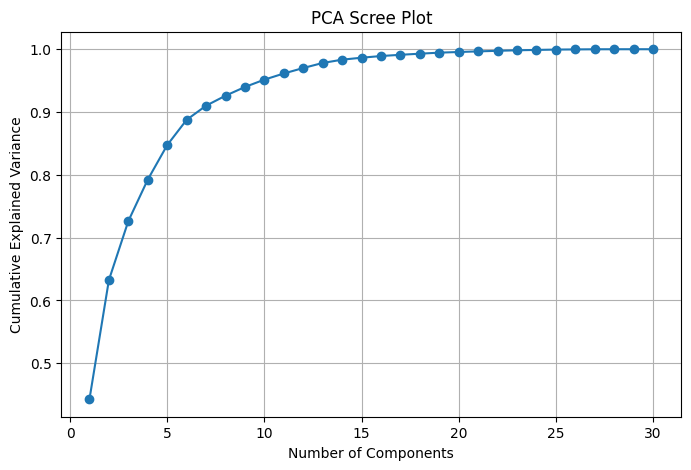

In [57]:
#Scree plot
# choosing number of components
pca_full = PCA()
pca_full.fit(x_scaled)
explained_variance = ( np.cumsum(pca_full.explained_variance_ratio_) )
plt.figure(figsize = (8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker = "o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid()
plt.show()